In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

checkpoints = {
    "MultVAE + L2": "TopKSAE-8192-369a6053.ckpt",
    "ELSA + L2": "TopKSAE-8192-26b50839.ckpt",
    "ELSA + Cosine": "TopKSAE-8192-d7b1a8cb.ckpt",    
}


# From Neurons to Tags

In [2]:
results = {}
for model, checkpoint in checkpoints.items():
    chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
    res = pd.read_csv(f"results/res_neuron_tag_{chckpt_name}.csv")
    results[model] = res


resultsT_to_N = {}
for model, checkpoint in checkpoints.items():
    chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
    res = pd.read_csv(f"results/res_tag_neuron_{chckpt_name}.csv")
    resultsT_to_N[model] = res


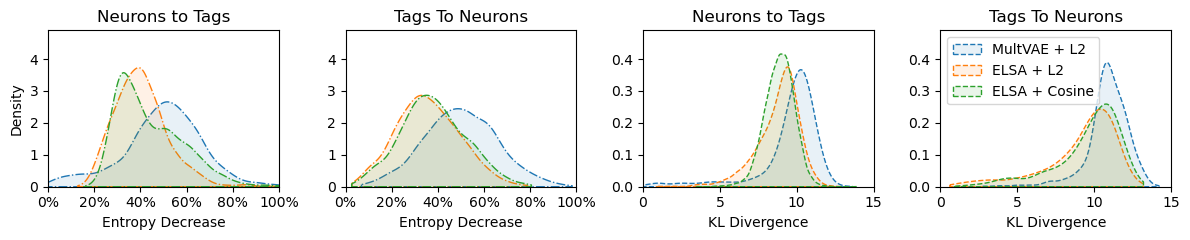

In [ ]:
# Initialize the plot
fig, (ax1,ax3,ax2,ax4) = plt.subplots(1,4, figsize=(12, 2.5))
for model, res in results.items():
    min_kldiv = res['KL_div'].min()
    max_kldiv = res['KL_div'].max()
    sns.kdeplot(res["KL_div"], ax=ax2, label=model, fill=True, linestyle="--", clip=(min_kldiv, max_kldiv), alpha=0.1)


    min_entropy = res['norm_entropy_diff'].min()
    max_entropy = res['norm_entropy_diff'].max()
    sns.kdeplot(res["norm_entropy_diff"], ax=ax1, label=model, fill=True, linestyle="-.", clip=(min_entropy, max_entropy), alpha=0.1)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Normalized Entropy Diff)")
ax2.set_ylabel("Density (KL divergence)")


for model, res in resultsT_to_N.items():
    min_kldiv = res['KL_div'].min()
    max_kldiv = res['KL_div'].max()
    sns.kdeplot(res["KL_div"], ax=ax4, label=model, fill=True, linestyle="--", clip=(min_kldiv, max_kldiv), alpha=0.1)


    min_entropy = res['norm_entropy_diff'].min()
    max_entropy = res['norm_entropy_diff'].max()
    sns.kdeplot(res["norm_entropy_diff"], ax=ax3, label=model, fill=True, linestyle="-.", clip=(min_entropy, max_entropy), alpha=0.1)

ax1.set_xlabel("Entropy Decrease")
ax2.set_xlabel("KL Divergence")
ax3.set_xlabel("Entropy Decrease")
ax4.set_xlabel("KL Divergence")

ax1.set_ylabel("Density")
ax2.set_ylabel("")
ax3.set_ylabel("")
ax4.set_ylabel("")

ax1.set_title("Neurons to Tags")
ax2.set_title("Neurons to Tags")
ax3.set_title("Tags To Neurons")
ax4.set_title("Tags To Neurons")

ax1.set_xlim(0.0, 1.0)
ax1.set_ylim(0.0, 4.9)
ax3.set_xlim(0.0, 1.0)
ax3.set_ylim(0.0, 4.9)

ax2.set_xlim(0.0, 15)
ax2.set_ylim(0.0, 0.49)
ax4.set_xlim(0.0, 15)
ax4.set_ylim(0.0, 0.49)

# Show the legend
ax4.legend(loc="upper left")
fig.tight_layout()


ax1.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Positions of the ticks
ax1.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])  # Custom labels
ax3.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Positions of the ticks
ax3.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])  # Custom labels

plt.tight_layout()
plt.savefig("results/figures/neuron_interpretability_MSD.pdf",bbox_inches='tight', dpi=600)

In [4]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("KL_div", ascending=False)
    dt = pd.concat([res.head(5)[["tag","entropy","KL_div"]],res.tail(1)[["tag","entropy","KL_div"]]])
    print(model)
    print(dt.to_latex(index=False, float_format="{:.2f}".format))



MultVAE + L2
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
Reggaeton & 2.61 & 14.21 \\
Rock Argentino & 3.59 & 14.10 \\
bluegrass & 3.56 & 13.92 \\
hardstyle & 0.67 & 13.89 \\
worship & 3.54 & 13.64 \\
favorites & 7.23 & 2.75 \\
\bottomrule
\end{tabular}

ELSA + L2
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
Kiwi & 2.73 & 13.20 \\
balkan & 4.10 & 13.14 \\
mashup & 3.24 & 13.06 \\
celtic punk & 4.00 & 12.86 \\
stand-up & 3.42 & 12.83 \\
favorites & 8.52 & 0.61 \\
\bottomrule
\end{tabular}

ELSA + Cosine
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
rock chileno & 4.27 & 13.20 \\
bachata & 3.48 & 13.16 \\
stand-up & 2.93 & 13.07 \\
J-rock & 4.33 & 13.00 \\
turkish & 3.66 & 13.00 \\
rock & 8.76 & 0.88 \\
\bottomrule
\end{tabular}



In [5]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("entropy", ascending=False)
    dt = res.head(2)[["tag","entropy","norm_entropy_diff"]]
    print(model)
    print(dt)
    print(dt.entropy/(1-dt.norm_entropy_diff))

MultVAE + L2
          tag   entropy  norm_entropy_diff
54  favorites  7.231406           0.068681
51       rock  7.220105           0.070136
54    7.764693
51    7.764693
dtype: float64
ELSA + L2
          tag   entropy  norm_entropy_diff
54  favorites  8.521678           0.027837
51       rock  8.459337           0.034949
54    8.765686
51    8.765686
dtype: float64
ELSA + Cosine
            tag   entropy  norm_entropy_diff
51         rock  8.761554           0.026369
52  alternative  8.688276           0.034512
51    8.998843
52    8.998843
dtype: float64


In [6]:
for model, res in results.items():
    res = res.sort_values("entropy", ascending=False)
    print(model)
    print(res.norm_entropy_diff.mean(),res.KL_div.mean())

MultVAE + L2
0.4950214248940263 9.541827073738057
ELSA + L2
0.40294198365989936 8.781957444125837
ELSA + Cosine
0.4408995962693099 8.87687027183392


In [7]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("entropy", ascending=False)
    print(model)
    print(res.norm_entropy_diff.mean(),res.KL_div.mean())

MultVAE + L2
0.4994111368302009 10.87151686156352
ELSA + L2
0.3582637318315634 9.141318186079078
ELSA + Cosine
0.38139325654217116 9.611814447261027


In [8]:
for model, res in resultsT_to_N.items():
    print(model)
    print((res.KL_div>10).sum() / res.shape[0])


MultVAE + L2
0.838562464346834
ELSA + L2
0.46092413006274957
ELSA + Cosine
0.54249857387336
